In [1]:
Sys.setenv(LANG = "en")
set.seed(0)
message("Seed set to 0")

suppressPackageStartupMessages({

    library(org.Hs.eg.db) # KEGG ensembl entrez symbol
    library(KEGGREST) # KEGG
    library(clusterProfiler)

    library(DESeq2) # normalized Matrix + PCA

    library(vegan) # PERMANOVA
    
    library(decoupleR) # CollecTRI

    library(fgsea) # NES
    
    # Tools and Plots
    library(dplyr)
    library(ggplot2)
    library(ggvoronoi)
    library(ggpubr)
    library(ggpmisc)
    library(ggrepel)
    library(RColorBrewer)
    library(stringr) # str_split
    library(reshape2) # melt
    library(org.Hs.eg.db)
    library(KEGGREST)
    

    
})

source("plotDesign.r")

meta <- read.csv("meta.csv", header = T)
count <- read.table("count_summary.txt", header=T)
symbol_ens <- readRDS("symbol_ensembl_entrez.RDS")

Seed set to 0



In [34]:
save_gg <- function(gg_obj, name, width=10, height=10){
    path = unlist(strsplit(x = name, split = "/")) 
    filename = tail(path, n=1)
    len_path = length(path)
    if(len_path > 1){
        path = paste0(path[1:len_path-1], collaps="/") 
        path = paste0(path, "/")
        
    }else  
        path = "./"
        
    file_split <- unlist(strsplit(x = filename, split = "\\.")) 
    if (length(file_split) < 2)
        stop("No extension found in filename : ", filename)
    ext = tail(file_split, n=1)
    file_without_ext =  paste0(file_split[1:length(file_split)-1], collaps=".") 

    ggsave(paste0(path, file_without_ext, ext), width=10, height=10)
    tryCatch(
        {write.csv(gg_obj$data, paste0(path, file_without_ext, "csv"))
        }, error = function(msg){
            message("csv error ignored")
        })
    saveRDS(gg_obj, paste0(path, file_without_ext, "RDS"))    
}

In [4]:
hsa_path_eg  <- keggLink("pathway", "hsa") %>% 
    tibble(pathway = ., eg = sub("hsa:", "", names(.)))

hsa_kegg_anno <- hsa_path_eg %>%
    mutate(
        symbol = mapIds(org.Hs.eg.db, eg, "SYMBOL", "ENTREZID"),
        ensembl = mapIds(org.Hs.eg.db, eg, "ENSEMBL", "ENTREZID")
    )

hsa_pathways <- keggList("pathway", "hsa") %>% 
    tibble(pathway = names(.), description = .)

hsa_pathways$parent <- hsa_pathways$grand <- NA

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [26]:
hsa_path_eg  <- keggLink("pathway", "hsa") %>% 
    tibble(pathway = ., eg = sub("hsa:", "", names(.)))

hsa_kegg_anno <- hsa_path_eg %>%
    mutate(
        symbol = mapIds(org.Hs.eg.db, eg, "SYMBOL", "ENTREZID"),
        ensembl = mapIds(org.Hs.eg.db, eg, "ENSEMBL", "ENTREZID")
    )

hsa_pathways <- keggList("pathway", "hsa") %>% 
    tibble(pathway = names(.), description = .)

hsa_pathways$parent <- hsa_pathways$grand <- NA
total = nrow(hsa_pathways)
for(i in 1:total){
    if(i %% 10 == 0)
        message(paste0(i,"/",total))
    tryCatch({
        KeggMeta <- keggGet(hsa_pathways$pathway[i])[[1]]$CLASS
        if(is.null(KeggMeta)) next
    },
    error = function(e){
        message(e)
        next
    })
    parents = as.vector(unlist(strsplit(KeggMeta,";")))
    hsa_pathways$parent[i] <-  parents[2]
    hsa_pathways$grand[i] <- parents[1]
}

hsa_kegg_anno$pathway_ <- str_split_i(hsa_kegg_anno$pathway,pattern = ":", i=2)
hsa_kegg_anno$parent <- hsa_pathways$parent[match(hsa_kegg_anno$pathway_, hsa_pathways$pathway)]
hsa_kegg_anno$grand <- hsa_pathways$grand[match(hsa_kegg_anno$pathway_, hsa_pathways$pathway)]
hsa_kegg_anno$description <- hsa_pathways$description[match(hsa_kegg_anno$pathway_, hsa_pathways$pathway)]
saveRDS(hsa_pathways, "hsa_pathways.RDS")
saveRDS(hsa_kegg_anno, "KEGG_annotation_gene_term.RDS")

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

10/368

20/368

30/368

40/368

50/368

60/368

70/368

80/368

90/368

100/368

110/368

120/368

130/368

140/368

150/368

160/368

170/368

180/368

190/368

200/368

210/368

220/368

230/368

240/368

250/368

260/368

270/368

280/368

290/368

300/368

310/368

320/368

330/368

340/368

350/368

360/368



In [ ]:
saveRDS(hsa_pathways, "hsa_pathways.RDS")

In [14]:
hsa_kegg_anno = readRDS("KEGG_annotation_gene_term.RDS")

# Filter Genes and prepare matrix 

In [5]:
#' Preprocess Gene Expression Matrix, Filtered low quality genes, and return DESeq normalized matrix
#'
#'
#' @param raw A matrix or data frame containing raw gene expression counts.
#'        Rows represent genes, and columns represent samples. Row names should be 
#'        Ensembl gene IDs.
#' @param validSymbols A data frame containing valid Ensembl gene IDs and HGNC symbols.
#'        Must include the columns `ensembl_gene_id` and `hgnc_symbol`.
#' @param countasZero A numeric threshold for treating counts as zero. Default is 0.
#'        Used for filtering genes based on expression levels.
#'
#' @return A list with the following components:
#'   counts: Matrix of filtered raw counts that passed quality control (QC).
#'   normalized: Matrix of normalized counts after DESeq2 size factor normalization
#'   statistics: statistics for genes and samples

prepMatrix <- function(raw, validSymbols, countasZero = 0){
	stopifnot(!is.null(rownames(raw)))
	stopifnot(is.matrix(raw) | is.data.frame(raw))
	
	filtered <- raw[rowSums(raw > countasZero) > ncol(raw)/3,]
	filtered <- filtered[rownames(filtered) %in% validSymbols$ensembl_gene_id[validSymbols$hgnc_symbol != ""],]
	gsg <- WGCNA::goodSamplesGenes(t(filtered))
	filtered <- filtered[gsg$goodGenes,]
	if(!gsg$allOK){
		if(any(!gsg$goodSamples))
			message("Info: ", paste0(colnames(filtered)[!gsg$goodSamples], collapse = ", "), " did not pass the WGCNA goodSample test. ", 
					"However these samples will not be filtered.")
		if(any(!gsg$goodGenes))
			message("Info: ", sum(!gsg$goodGenes), "Genes did not pass the WGCNA goodSample test after default filtering. ", 
					"However these genes will not be filtered.")
	}
	
	DE <- DESeqDataSetFromMatrix(filtered, colData = data.frame(colnames(filtered)), design = ~1) 
	DE <- estimateSizeFactors(DE)
	normalized <- counts(DE, normalized=TRUE)
	message("#Genes before QC: ",  nrow(raw) , " - #Genes after QC: ", nrow(filtered))
	return(list(counts = filtered, normalized = normalized, 
				statistics = list(genes = data.frame(goodGenes = gsg$goodGenes, 
														   meanCounts = rowMeans(as.matrix(filtered)), 
														   medianCounts = rowMedians(as.matrix(filtered)), 
														   min = apply(filtered, 1,min), max = apply(filtered, 1,max), 
														   symbol = validSymbols$hgnc_symbol[match(rownames(filtered), validSymbols$ensembl_gene_id)])
										,
														   
										samples = data.frame(goodGenes = gsg$goodSamples, 
														   meanCounts = colMeans(as.matrix(filtered)), 
														   medianCounts = colMedians(as.matrix(filtered)), 
														   min = apply(filtered, 2,min), max = apply(filtered, 2,max))
										)
				)
		   )

}

#' Calculate z score of numeric vector
zscore <- function(x)
    return((x - mean(x))/sd(x))

#' Compute mean z-score per sample
#'
#' @param mat A matrix of gene expression values. 
#' @param genes a vector of genes
#'
#' @return vector of mean sample z-scores based on the provided gene module

ZModuleScore <- function(mat, genes){
	inMat_Genes <- genes %in% rownames(mat)
	NA_Genes <- genes[!inMat_Genes]
	if(!is.null(NA_Genes) & length(NA_Genes) > 0) 
		message("Genes will be excluded because they are not included in matrix: ", 
                paste0(NA_Genes, collapse = ","))
	genes <- genes[inMat_Genes]
	stopifnot(length(genes) > 0)
	mat_subset <- mat[genes,]
	zMean <- t(scale(t(mat_subset))) %>% colMeans
	
	return(zMean)
}


#convert Ensemble <> Symbol
getEns <- function(symb ,conv=symbol_ens){
    inList <- symb %in% symbol_ens$hgnc_symbol
    if (sum(!inList) != 0){
        message(paste0(symb[!inList], collapse = ","), " not found! Gene will be excluded")
        symb <- symb[inList]
    }
    if (length(symb) == 0)
        return(FALSE)
    
    return(symbol_ens$ensembl_gene_id[match(symb, symbol_ens$hgnc_symbol)])    
}
getSymb <- function(ens ,conv=symbol_ens, ignoreNA = FALSE){
    inList <- ens %in% symbol_ens$ensembl_gene_id
    if (sum(!inList) != 0 & !ignoreNA){
        message(paste0(ens[!inList], collapse = ","), " not found! Gene will be excluded")
        ens <- ens[inList]
    }
    if (length(ens) == 0 & !ignoreNA)
        return(FALSE)
    
    return(symbol_ens$hgnc_symbol[match(ens, symbol_ens$ensembl_gene_id)])    
}


In [6]:
counts_filtered <- prepMatrix(count, validSymbols = symbol_ens, countasZero = 0)

 Flagging genes and samples with too many missing values...
  ..step 1


#Genes before QC: 58051 - #Genes after QC: 22058



# PCA Plot

In [7]:
DES <- DESeqDataSetFromMatrix(counts_filtered$counts, 
                              colData = meta, 
                              design = ~sex+age+diagnosis) 
DES <- estimateSizeFactors(DES)
vsd <- vst(DES, blind=T)

vars <- apply(assay(vsd), 1, sd)
select <- names(head(vars[order(vars, decreasing=T)], n = 500))
pca <- prcomp(t(assay(vsd)[select,]), center = T)
propOfVar <- round(summary(pca)$importance[2,] * 100, digits = 1)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.



Warning message:
“`fortify(<SpatialPolygonsDataFrame>)` was deprecated in ggplot2 3.4.4.
ℹ Please migrate to sf.”


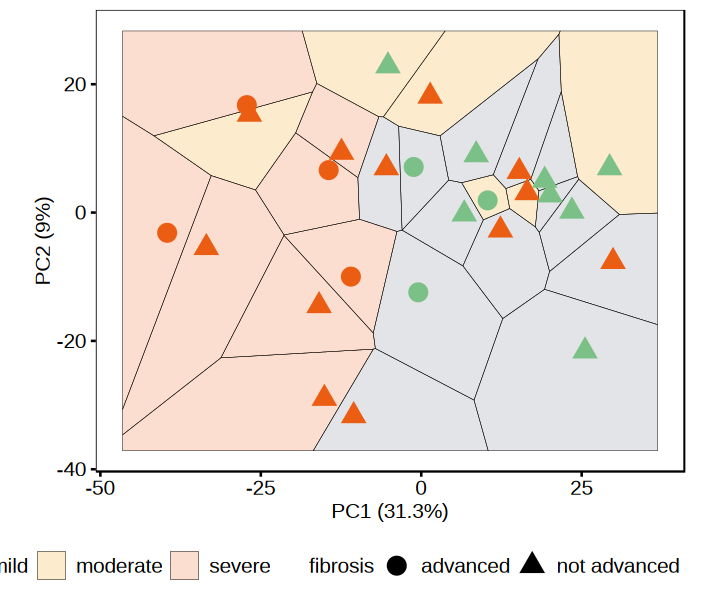

In [54]:
options(repr.plot.height=5, repr.plot.width=6)

matched <- match(rownames(pca$x), meta$sample)
library(ggvoronoi)
p_pca <- ggplot(data.frame(pca$x[,1:2], 
                  diag = meta$diagnosis[matched], 
                  mHAI = meta$mHAI_category[matched],
                  fibrosis = ifelse(meta$fibrosis[matched] > 3, "advanced", "not advanced")), 
                
       aes(x=PC1, y=PC2, color=diag)) + 
geom_voronoi(aes(fill=mHAI), alpha=0.2, linewidth=0.1, color="black") + 
geom_point(aes(shape=fibrosis), size=5)  + 
scale_color_manual(values = c(AIH = colors$base$AIH, PBC = colors$base$PBC)) + 
scale_fill_manual(values = c(colors$mHAI_tri)) +
labs(x=paste0("PC1 (", propOfVar[1],"%)"), 
     y=paste0("PC2 (", propOfVar[3],"%)"), color="") + 
theme_paper(aspect.ratio = NULL) + coord_fixed() + theme(legend.position="bottom")

p_pca
save_gg(p_pca, "panels/Figure1b_PCA.pdf")

In [15]:
vsd_matrix <- t(assay(vsd)[select,])

In [16]:
print(adonis2(vsd_matrix ~ mHAI + diag + fibrosis, data=p_pca$data, by="margin"))

Permutation test for adonis under reduced model
Marginal effects of terms
Permutation: free
Number of permutations: 999

adonis2(formula = vsd_matrix ~ mHAI + diag + fibrosis, data = p_pca$data, by = "margin")
         Df SumOfSqs      R2      F Pr(>F)  
mHAI      2 0.020544 0.12269 2.0737  0.030 *
diag      1 0.006061 0.03620 1.2237  0.236  
fibrosis  1 0.006776 0.04046 1.3679  0.201  
Residual 22 0.108975 0.65080                
Total    26 0.167447 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


# Inflammatory Response 

In [56]:
inflammatoryResponse <- read.gmt(gmtfile = "HALLMARK_INFLAMMATORY_RESPONSE.v2023.2.Hs.gmt")

# calculate score22
zmean <- ZModuleScore(counts_filtered$normalized, genes = getEns(inflammatoryResponse$gene))

Warning message in readLines(gmtfile):
“incomplete final line found on 'HALLMARK_INFLAMMATORY_RESPONSE.v2023.2.Hs.gmt'”
Genes will be excluded because they are not included in matrix: ENSG00000108688,ENSG00000108342,ENSG00000105371,ENSG00000124479,ENSG00000056291,ENSG00000082556,ENSG00000169836



In [57]:
data <- data.frame(score = zmean, 
                   diag = meta$diagnosis[match(names(zmean), meta$sample)], 
                   mHAI = meta$mHAI[match(names(zmean), meta$sample)], 
                   altULN = meta$altULN[match(names(zmean), meta$sample)], 
                   fibrosis = meta$fibrosis[match(names(zmean), meta$sample)],
                   mHAI_cat = meta$mHAI_cat[match(names(zmean), meta$sample)]
                   )
data$mHAI_cat[data$diag == "PBC"] <- "PBC"
data$mHAI_cat <- factor(data$mHAI_cat, levels = c("PBC", "mild", "moderate", "severe"))
data$fibrosis_cat <- ifelse(data$fibrosis > 3, "advanced", "not advanced")

In [58]:
options(repr.plot.width = 3, repr.plot.height=5)

# BOXPLOT mHAI / Diagnosis vs Score
p1 <- ggplot(data, aes(x=mHAI_cat , y= score)) +  
    geom_jitter(aes(shape=fibrosis_cat, color=mHAI_cat), size=3, width=0.15) +
    geom_boxplot(aes(fill= mHAI_cat), alpha=0.2) + 
    geom_pwc(method = "wilcox.test",
             p.adjust.method = "fdr", 
             label = "Wilcoxon, italic(p[adj]) = {p.adj.format}", hide.ns=T) +  
    scale_fill_manual(values =  colors$mHAI_tri_with_PBC)  + 
    scale_color_manual(values =  colors$mHAI_tri_with_PBC)  +
    #set same range of z-score 
    ylim(c(-0.9, 1.2)) + 
    labs(y="mean z-score", x="AIH - mHAI") + 
    theme_bw() + 
    theme(aspect.ratio = 1, legend.position="none",  
          axis.line = element_blank(), panel.grid = element_blank()) 

save_gg(p1, "panels/Figure1c_left.pdf")

# SCATTERPLOT / Linear regression ALT vs Score
p2 <- ggplot(data, 
             aes(x=altULN, y=score, group=diag)) +  
    geom_smooth(data=subset(data, diag == "PBC"),  aes(x=altULN, y=score), 
                method=lm,  color = colors$base$PBC, se =FALSE, alpha=0.1) +  
    geom_smooth(method=lm,  color = "black", fill = "grey80") + 
    geom_point(aes(shape=fibrosis_cat, color=mHAI_cat), size=3) + 
    stat_poly_eq(use_label(c("R2", "p.value"))) +
    scale_color_manual(values =  colors$mHAI_tri_with_PBC)  +
    geom_vline(xintercept = 1, linetype="dotted", color="grey60") + 
    scale_x_log10() + 
    #set same range of z-score 
    ylim(c(-0.9, 1.2)) +
    labs(x= "ALT/ULN", y="mean z-score") +
    theme_bw() + theme(aspect.ratio = 1, legend.position = "none",
    axis.line = element_blank(), panel.grid = element_blank()) 

save_gg(p2, "panels/Figure1c_right.pdf")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


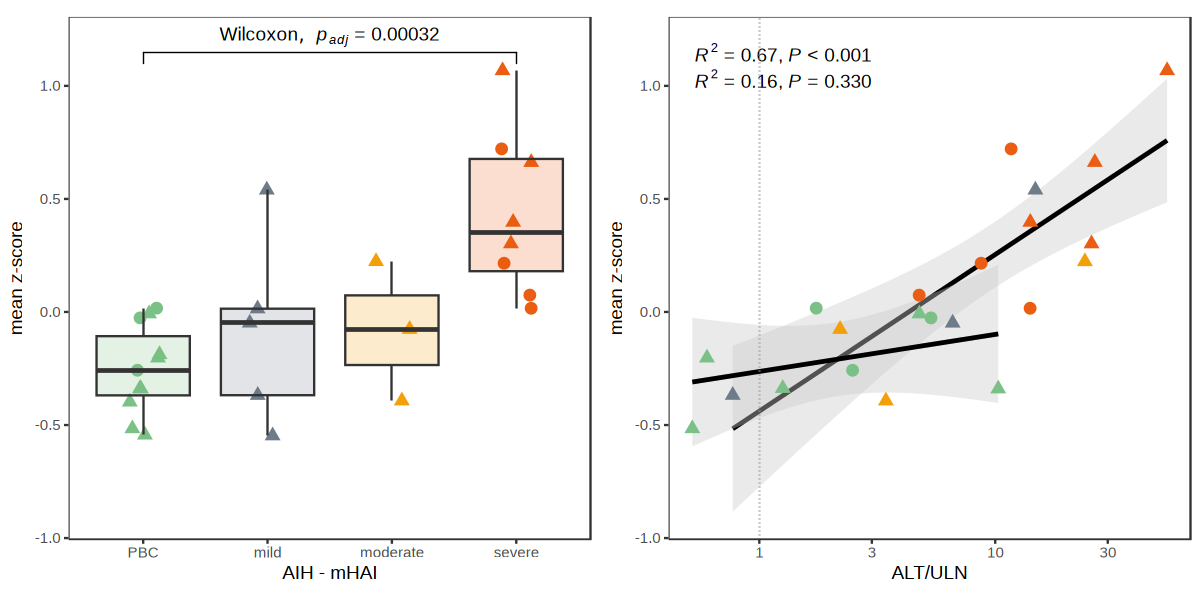

In [20]:
options(repr.plot.width = 10, repr.plot.height=5)
cowplot::plot_grid(p1,p2, nrow=1)

In [21]:
kruskal.test(score ~ mHAI_cat, data = data)


	Kruskal-Wallis rank sum test

data:  score by mHAI_cat
Kruskal-Wallis chi-squared = 13.362, df = 3, p-value = 0.003915


# Gene Correlation

In [8]:
# Warning this can take some time

# Which features to test; input column names of metaData
features <- c("mHAI", "fibrosis", "altULN")

metaData <- subset(meta, diagnosis == "AIH")
norm_symbol <- counts_filtered$normalized[,metaData$sample]
rownames(norm_symbol) <- getSymb(rownames(norm_symbol))
stopifnot(all(colnames(norm_symbol) == metaData$sample))
stopifnot(all(features %in% colnames(metaData)))

# Create Matrices
C_rho <- C_test <- matrix(NA, 
                          nrow = nrow(norm_symbol) , 
                          ncol = length(features), 
                          dimnames = list(rownames(norm_symbol), 
                                                    features))

for(f in features){
    message(f)
    feature_values <- metaData[,f]
    names(feature_values) <- metaData[, "sample"]
    feature_values <- feature_values[!is.na(feature_values)] 
    subCounts <- norm_symbol[,names(feature_values)] %>% as.matrix
    suppressWarnings({
        cor_res <- apply(subCounts, 1, 
                            function(x){ res = cor.test(x, y=feature_values, method="spearman"); 
                                 return(c(cor=unname(res$estimate), p=res$p.value))})
                      })
    C_rho[,f] <- cor_res[1,]
    C_test[,f] <- cor_res[2,]                                
}

correlation_matrices = list(rho = C_rho, sig = C_test)
saveRDS(correlation_matrices, "correlation_matrices.RDS")

mHAI

fibrosis

altULN



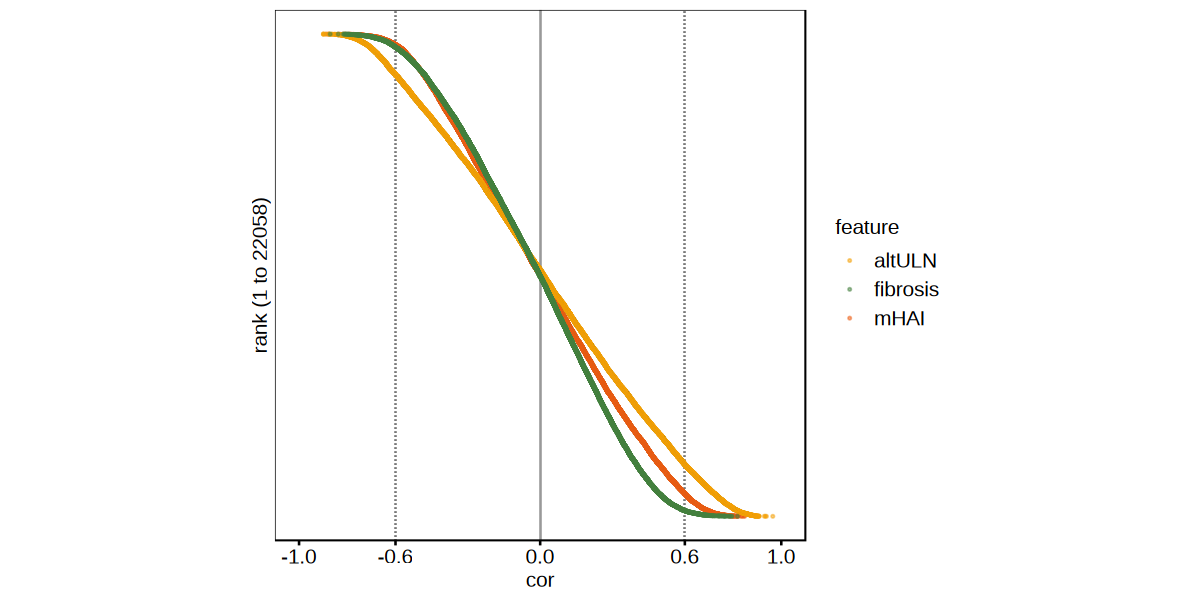

In [59]:
options(repr.plot.width=10, repr.plot.height=5)

ggdf <- rbind(
     data.frame(cor = sort(C_rho[, "mHAI"], decreasing = T) %>% unname, 
                         rank = 1:nrow(C_rho), feature = "mHAI"),
      data.frame(cor = sort(C_rho[, "altULN"], decreasing = T) %>% unname, 
                 rank = 1:nrow(C_rho), feature = "altULN"),
      data.frame(cor = sort(C_rho[, "fibrosis"], decreasing = T) %>% unname, 
                 rank = 1:nrow(C_rho), feature = "fibrosis")
)

p = ggplot(ggdf, aes(y=rank, x=cor, color=feature)) + 
geom_vline(xintercept = c(-0.6, 0.6), linetype="dotted") + 
geom_vline(xintercept = 0, color="gray60") +
geom_point(alpha=0.5, size=0.3) + 
scale_color_manual(values = c(mHAI = "#EB5D12", fibrosis = "#44803F", altULN = "#F39F07")) +
scale_x_continuous(breaks = c(-1,-0.6,0,0.6,1), limits = c(-1,1)) + 
labs(y=paste0("rank (1 to ",nrow(C_rho), ")")) +  
theme_paper() + theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())
p 
save_gg(p, "panels/supp_Figure1a.pdf", width=7, height=7)

# Enrichment

In [60]:
KEGG_List <- list()
for(p in names(table(hsa_kegg_anno$pathway_))){
    KEGG_List[[p]] <- hsa_kegg_anno$symbol[hsa_kegg_anno$pathway_ == p] %>% .[!duplicated(.)]

}

features <- colnames(C_rho)
KEGG_enrich <- list()
for(f in features){
    ranks <- C_rho[,f]
    #ranks[ranks == Inf] <- max(ranks[ranks != Inf])
    #ranks[ranks == -Inf] <- min(ranks[ranks != -Inf])
    KEGG_enrich[[f]] <- fgsea(pathways = KEGG_List, stats = ranks)
    KEGG_enrich[[f]]$feature = f

}
KEGG_enrichment_data <- do.call(rbind.data.frame, KEGG_enrich)
KEGG_enrichment_data$description <- hsa_pathways$description[match(KEGG_enrichment_data$pathway, hsa_pathways$pathway)]
KEGG_enrichment_data$description <- str_split_i(string = KEGG_enrichment_data$description , " - ", i = 1) # Remove Homo...
KEGG_enrichment_data$grand <- hsa_pathways$grand[match(KEGG_enrichment_data$pathway, hsa_pathways$pathway)]
KEGG_enrichment_data$parent <- hsa_pathways$parent[match(KEGG_enrichment_data$pathway, hsa_pathways$pathway)]
KEGG_enrichment_data$total_p_adj <- p.adjust(KEGG_enrichment_data$pval, "fdr")
KEGG_enrichment_data <- KEGG_enrichment_data %>% mutate(sig_level = case_when(
            total_p_adj > 0.05 ~ "",
            total_p_adj <= 0.05 & total_p_adj > 0.01 ~ "*",
            total_p_adj <= 0.01 & total_p_adj > 0.001 ~ "**",
            total_p_adj <= 0.001 & total_p_adj > 0.0001 ~ "***",
            total_p_adj <= 0.0001 ~ "****"))

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (78.61% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are duplicate gene names, fgsea may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (79% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are duplicate gene names, fgsea may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (87.26% of the list).
The order of those tied genes will be arbitra

csv error ignored



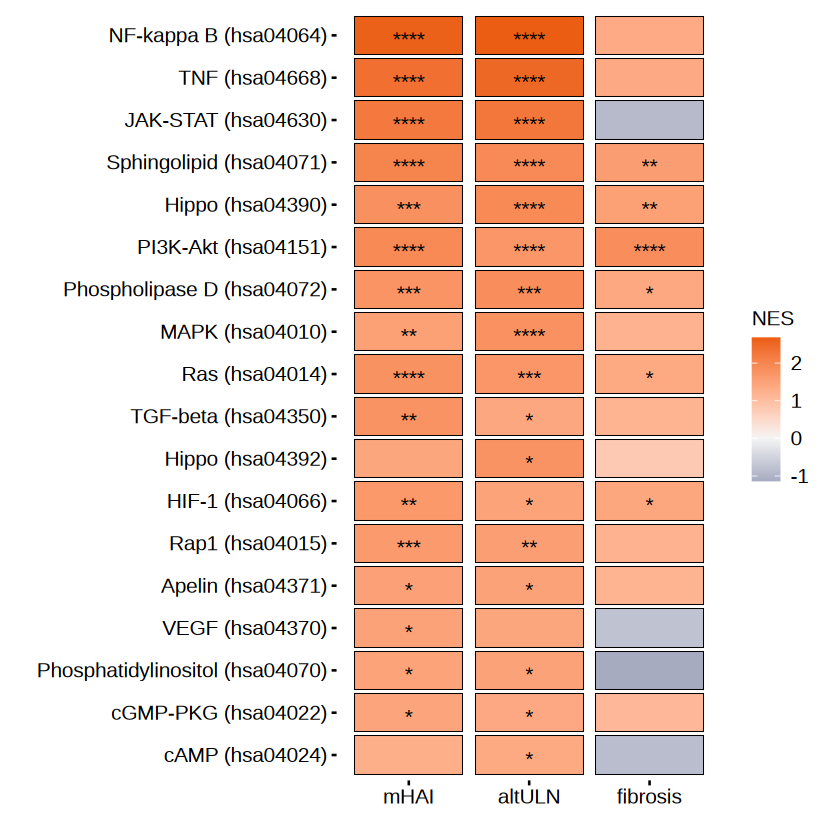

In [61]:
keep_terms = KEGG_enrichment_data %>% 
    group_by(pathway) %>% 
    summarise(sum = sum(total_p_adj < 0.05)) %>% 
    filter(sum > 0) %>% 
    .$pathway

KEGG_enrichment_signaling <- subset(KEGG_enrichment_data, pathway %in% keep_terms & parent == " Signal transduction") 
KEGG_enrichment_signaling$description <- str_split_i(string = KEGG_enrichment_signaling$description , " signaling ", i = 1)
KEGG_enrichment_signaling$description <- paste0(KEGG_enrichment_signaling$description , " (", KEGG_enrichment_signaling$pathway, ")") 
order_description <- KEGG_enrichment_signaling %>% group_by(description) %>% summarise(max = max(NES)) %>% arrange(max) %>% .$description

plot_NES_sig_transduction <- ggplot(KEGG_enrichment_signaling, aes(x = factor(feature, levels = c("mHAI","altULN", "fibrosis")),
           y = factor(description, levels = order_description), 
           fill = NES,
           label = sig_level)) +
           #label = round(total_p_adj, 3))) +
geom_tile(width= 0.9, height = 0.9, color="black") +
geom_text(nudge_y = -0.1) +
colors$palette$DarkBlue_Red$ggfill() +
labs(x = "", y= "") + 
theme_paper("blank", aspect.ratio = 2/1)

options(repr.plot.width=7, repr.plot.height=7)
plot_NES_sig_transduction



save_gg(plot_NES_sig_transduction, "panels/Figure1d.pdf", width=7, height=7)





## Cytokines

In [40]:
# Load cytokines 
splitVecRegExp <- function(vec, regex){
    splitList <- list()
    splitNumber <- grep(regex, vec)
    splitNumber <- c(splitNumber, length(vec))
    
    if(splitNumber[1] > 1)
        splitList[["default"]] <- vec[1:splitNumber[1]-1]
    for(i in 1:length(splitNumber)){
        if(i == length(splitNumber)) next
        splitList[[vec[splitNumber[i]]]] <- vec[(splitNumber[i]+1):(splitNumber[i+1]-1)] 
    }
    return(splitList)
}

# use hsa04052
#lines <- readLines(
#  "http://www.kegg.jp/kegg-bin/download_htext?htext=hsa04052.keg&format=htext" )
lines <- readLines("hsa04052.keg")
lineVec <- lines[grep("^[BC]\\s+", lines)]
lineVec <- splitVecRegExp(lineVec, "^B") 
lineVec <- sapply(lineVec, function(k) sapply(str_split(k, "\\s{1}"), 
                                   function(x) str_sub(x[6], end=-2)))
names(lineVec) <- str_split_i(string = names(lineVec), pattern = "\\s{2}", i = 2)   
cytokines <- lineVec    
renameCyto <- c("Interleukines", "Interferons", "CSF", "Chemokines", "TNF", "Transforming growth factors",
                     "Growth factors", "GPCR Neuropeptides", "unclassified Neuropeptides")                                              
names(cytokines) <- renameCyto

In [41]:
# Select cytokines avaiable in rho matrix
selected_cyto <- cytokines %>% unlist %>% .[. %in% rownames(C_rho)]
df_rho_cyto <- C_rho[selected_cyto, c("mHAI",  "altULN")] %>% melt %>% rename(cytokine=Var1, feature=Var2, rho=value)
df_p_cyto <- C_test[selected_cyto, c("mHAI", "altULN")] %>% melt %>% rename(cytokine=Var1, feature=Var2, p=value)

# transfer p values and cat 
df_rho_cyto$pVal <- df_p_cyto$p #p.adjust(df_p_cyto$p, "fdr")
#df_rho_cyto$pValadj <- p.adjust(df_p_cyto$p, "fdr")
df_rho_cyto <- df_rho_cyto %>% mutate(label = case_when(pVal > 0.05 ~ "",
            pVal <= 0.05 & pVal > 0.01 ~ "*",
            pVal <= 0.01 & pVal > 0.001 ~ "**",
            pVal <= 0.001 ~ "***"))

df_rho_cyto$cat <- names(selected_cyto) %>% 
str_split_i(pattern = "[0-9]", i = 1) %>% factor(levels=renameCyto)


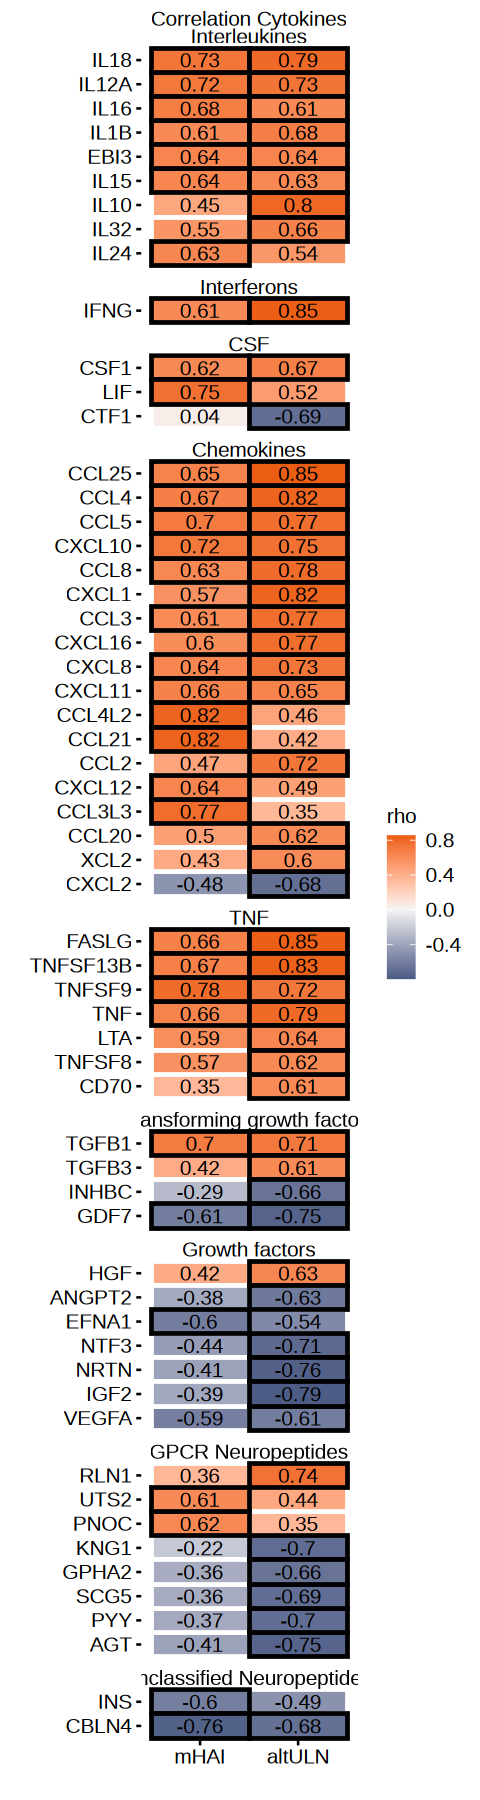

In [62]:
options(repr.plot.width=4, repr.plot.height=15)

# only select cytokines which are significant in at least one faeture
cyto_significant_rho <- selected_cyto[rowSums(abs(C_rho[selected_cyto, c("mHAI", "altULN")]) > 0.6) != 0]
ggdf <- subset(df_rho_cyto, cytokine %in% cyto_significant_rho)

# rho values as labels
p <- ggplot(ggdf , aes(y=reorder(cytokine, rho, decreasing = FALSE), 
                        x=factor(feature, levels = c("mHAI", "altULN")), 
                        fill=rho)) + 
geom_tile(color="white", size=1) +
geom_tile(data = subset(ggdf , abs(rho) >= 0.6), color="black", size=1) +
geom_text(aes(label=round(rho,2)), nudge_y = -0.01) +
colors$palette$DarkBlue_Red$ggfill() + 
scale_color_manual(values = c("black", "white")) + 
labs(x="", y="", fill="rho", title="Correlation Cytokines") + 
theme_paper(bordertype = "blank", aspect.ratio = NULL) +
ggforce::facet_col(facets = vars(cat), scales = "free_y", space = "free") 

p
save_gg(p, "panels/Figure1e_suppFigure1b.pdf")

# TF Activity

In [46]:
# Load collectri net
net <- get_collectri(organism='human', split_complexes=FALSE)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


In [47]:
cor_collectri <- run_ulm(mat=C_rho, net=net, .source='source', .target='target', .mor='mor', minsize = 5)
cor_collectri$p_value_adj <- p.adjust(cor_collectri$p_value, "fdr")

In [48]:
get_top_TF <- function(data, cond, n = 5){
    if(sum(cond %in% data$condition) == 0)
        stop("provided condition not in data included")
    
    data <- subset(data, condition == cond) %>% arrange(desc(score))
    data <- rbind(head(data), tail(data))
    data <- subset(data, p_value_adj < 0.05)
    return(data)


}

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <88>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <92>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <88>”
Warning message in grid.Call.graph

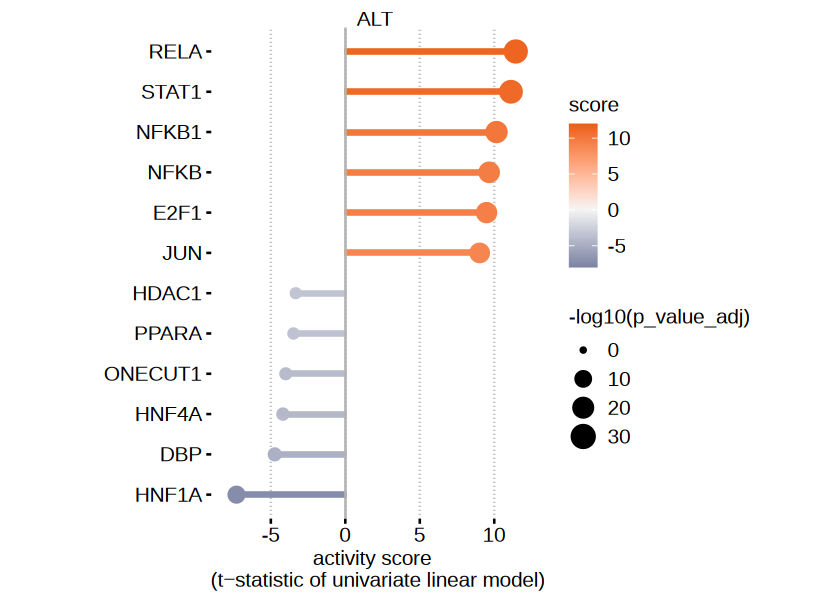

In [64]:
collectri_alt <- get_top_TF(cor_collectri, "altULN")

options(repr.plot.width=7, repr.plot.height=5)
p_ALT <- ggplot(collectri_alt, 
       aes(x=score, 
           y=reorder(source, score), 
           color=score,
           fill = score
          )
) + 
geom_bar(stat = "Identity", width=0.1) + 
geom_point(aes(size = -log10(p_value_adj))) + 
geom_vline(xintercept = 0, color="gray70") + 
labs(y="", x="activity score \n (t−statistic of univariate linear model)", title="ALT") + 
colors$palette$DarkBlue_Red$ggfill(limits=c(-8,12)) +
colors$palette$DarkBlue_Red$ggcolor(limits=c(-8,12)) +
scale_size_continuous(limits=c(0,30)) + 
scale_x_continuous(limits=c(-8,12)) + 
theme_paper("blank", aspect.ratio = 1.5/1) + theme(panel.grid.major.x = element_line(color = "gray70", linetype = "dotted"))

p_ALT
save_gg(p_ALT, "panels/Figure1f.pdf")

        

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <88>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <92>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': dot substituted for <88>”
Warning message in grid.Call.graph

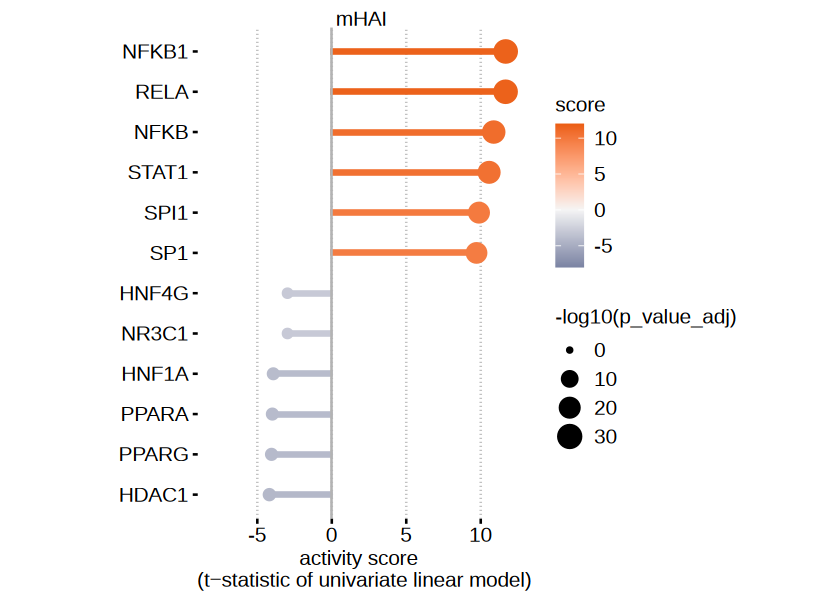

In [52]:
collectri_mHAI <-  get_top_TF(cor_collectri, "mHAI")

options(repr.plot.width=7, repr.plot.height=5)
p_mHAI <- ggplot(collectri_mHAI, 
       aes(x=score, 
           y=reorder(source, score), 
           color=score,
           fill = score
          )
) + 
geom_bar(stat = "Identity", width=0.1) + 
geom_point(aes(size = -log10(p_value_adj))) + 
geom_vline(xintercept = 0, color="gray70") + 
labs(y="", x="activity score \n (t−statistic of univariate linear model)", title="mHAI") + 
colors$palette$DarkBlue_Red$ggfill(limits=c(-8,12)) +
colors$palette$DarkBlue_Red$ggcolor(limits=c(-8,12)) +
scale_size_continuous(limits=c(0,30)) + 
scale_x_continuous(limits=c(-8,12)) + 

theme_paper("blank", aspect.ratio = 1.5/1) + theme(panel.grid.major.x = element_line(color = "gray70", linetype = "dotted"))

p_mHAI
save_gg(p_mHAI, "figures/ALT_TF_activity.pdf")




Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': - substituted for − (U+2212)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for ' (t−statistic of univariate linear model)' in 'mbcsToSbcs': - substituted for − (U+2212)”


pdf 
  3

pdf 
  2

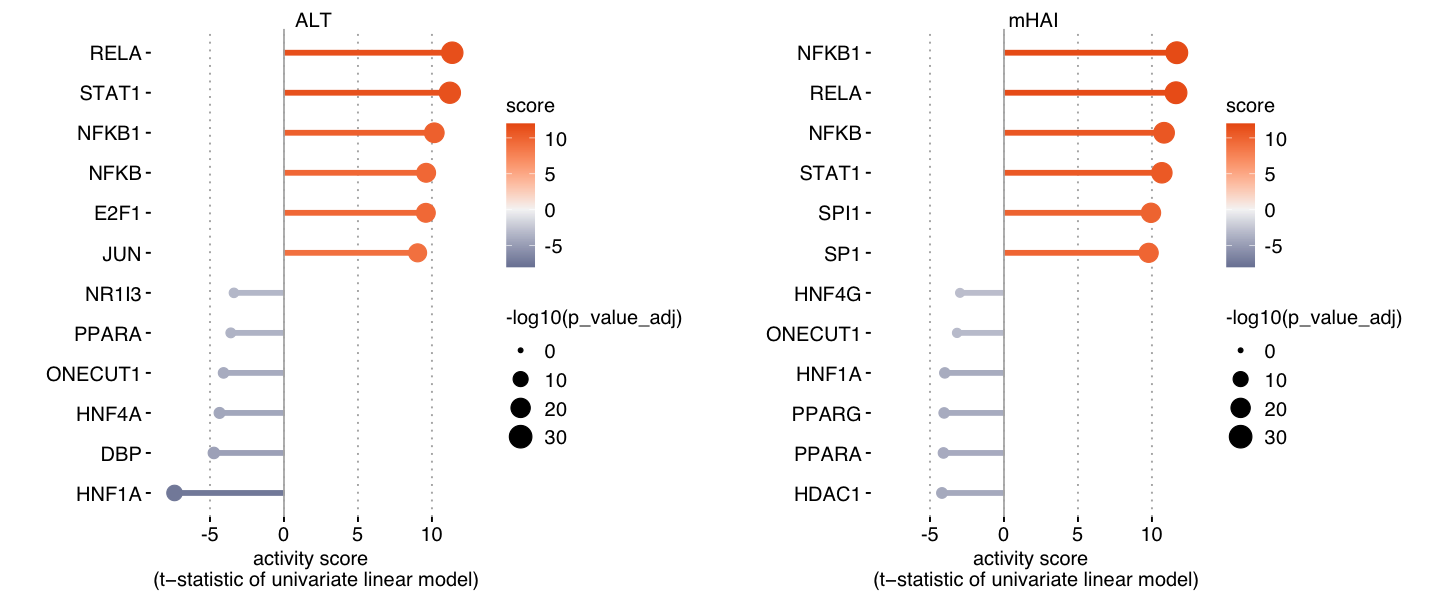

In [883]:
options(repr.plot.width=12, repr.plot.height=5)
cowplot::plot_grid(p_ALT, p_mHAI, ncol = 2)

dev.copy(pdf, "TF_activity.pdf", width=12, height=5)
dev.off()

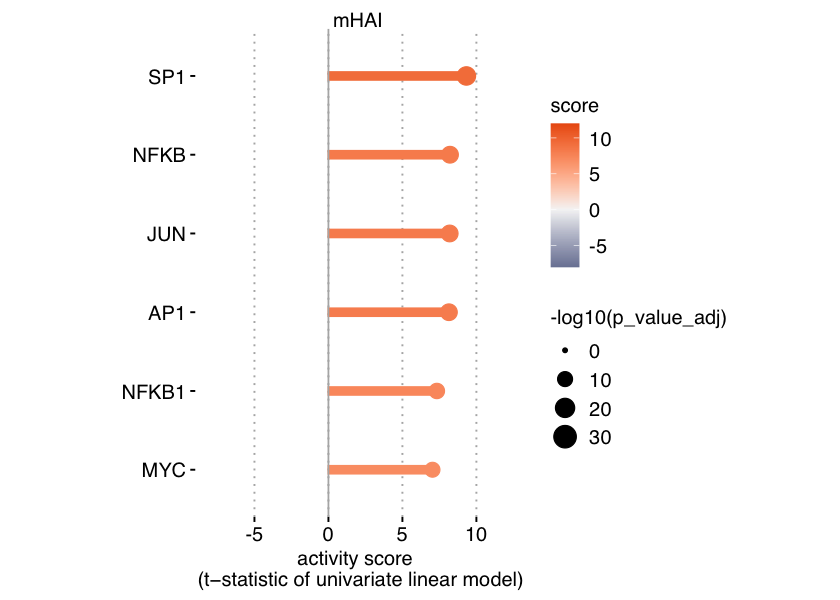

In [882]:
collectri_fibrosis <- get_top_TF(cor_collectri, "fibrosis")

options(repr.plot.width=7, repr.plot.height=5)
ggplot(collectri_fibrosis, 
       aes(x=score, 
           y=reorder(source, score), 
           color=score,
           fill = score
          )
) + 
geom_bar(stat = "Identity", width=0.1) + 
geom_point(aes(size = -log10(p_value_adj))) + 
geom_vline(xintercept = 0, color="gray70") + 
labs(y="", x="activity score \n (t−statistic of univariate linear model)", title="mHAI") + 
colors$palette$DarkBlue_Red$ggfill(limits=c(-8,12)) +
colors$palette$DarkBlue_Red$ggcolor(limits=c(-8,12)) +
scale_size_continuous(limits=c(0,30)) + 
scale_x_continuous(limits=c(-8,12)) + 

theme_paper("blank", aspect.ratio = 1.5/1) + theme(panel.grid.major.x = element_line(color = "gray70", linetype = "dotted"))



# Session

In [53]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/r-scrna/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] reshape2_1.4.5              stringr_1.6.0              
 [3] RColorBrewer_1.1-3          ggrepel_0.9.6              
 [5] ggpmisc_0.6.2               ggpp_0.5.9                 
 [7] ggpubr_0.6.2                ggvoronoi_0.8.6            
 [9] ggplot2_4.0.1               dplyr_1.1